# Exploratory Data Analysis and Data Cleaning

On this part the focus is to get a better understanding about the data, the business context, what does the target modelize getting a deep understanding, and later start to clean and prepare the data to be feeded into the models.

So along the EDA these questions will be responded

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gc
from pathlib import Path
from sklearn.model_selection import train_test_split

# 1. Loading the Data

In [2]:
datos = Path().resolve().parent / "data" / "accepted_2007_to_2018Q4.csv"

In [3]:
df = pd.read_csv(datos)

/tmp/ipykernel_34828/3753337816.py:1: DtypeWarning: Columns (0: id, 1: desc, 2: next_pymnt_d, 3: verification_status_joint, 4: sec_app_earliest_cr_line, 5: hardship_type, 6: hardship_reason, 7: hardship_status, 8: hardship_start_date, 9: hardship_end_date, 10: payment_plan_start_date, 11: hardship_loan_status, 12: debt_settlement_flag_date, 13: settlement_status, 14: settlement_date) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(datos)


First look at our data

In [4]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
print(f"This dataframe has {df.shape[0]} rows and {df.shape[1]} columns")

This dataframe has 2260701 rows and 151 columns


The first question that may come to your mind is, what do we want to esimate from this data?

The answer is Probability of Default (PD from now on), trying to fit a specific time span, for example Probability of default on 12 months.

The target provided by the data is the following :

In [6]:
df["loan_status"].value_counts()

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

For this project, categories that don't mean the loan has ended are going to be dropped, as they do not contribute to the scope of this project, codifying 1 as default, and 0 as fully paid

In [7]:
fully_paid_categories = [
    "Fully Paid",
    "Does not meet the credit policy. Status:Fully Paid"
]
default_categories = [
    "Charged Off",
    "Default",
    "Does not meet the credit policy. Status:Charged Off"
]

df_resolved = df[df["loan_status"].isin(fully_paid_categories + default_categories)].copy()
df_resolved["target"] = df_resolved["loan_status"].isin(default_categories).astype(int)
del df


In [8]:
print(f"This dataframe has {df_resolved.shape[0]} rows and {df_resolved.shape[1]} columns")

This dataframe has 1348099 rows and 152 columns


And another question that naturally follows the nature of the target, on what time span are we computing the probability of someone defaulting, because the PD of someone defaulting it's not the same on the same month the loan was approved or on the sixth or twelfth month.

This is going to be estimated from the data we have, as it is not provided by the original data.

In [9]:
df_resolved["issue_d"] = pd.to_datetime(df_resolved["issue_d"], format="%b-%Y")
df_resolved["last_pymnt_d"] = pd.to_datetime(df_resolved["last_pymnt_d"], format="%b-%Y")

df_resolved["months_to_resolution"] = (
    (df_resolved["last_pymnt_d"].dt.year - df_resolved["issue_d"].dt.year) * 12 +
    (df_resolved["last_pymnt_d"].dt.month - df_resolved["issue_d"].dt.month)
)

df_resolved.groupby("target")["months_to_resolution"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,1078739.0,22.116308,12.907908,0.0,11.0,22.0,35.0,70.0
1,267035.0,16.057599,9.842059,0.0,8.0,14.0,22.0,66.0


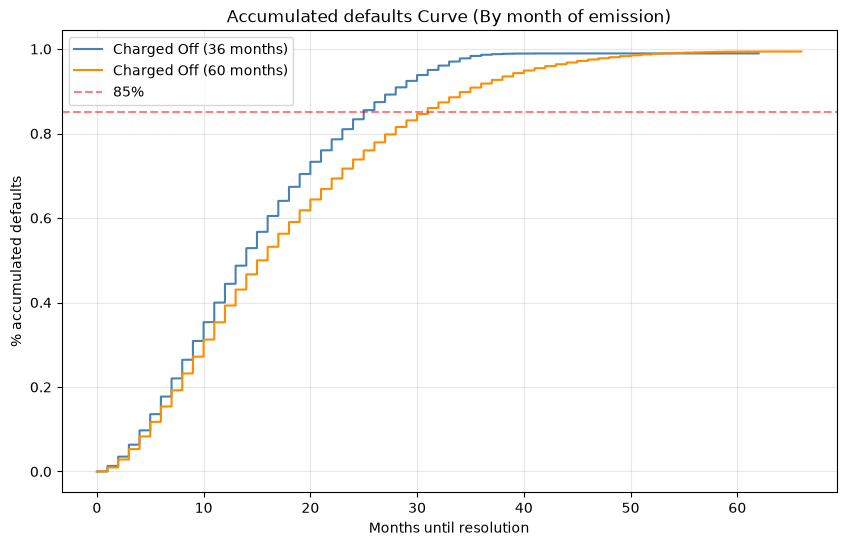

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

for term_value, color in [(" 36 months", "steelblue"), (" 60 months", "darkorange")]:
    subset = df_resolved[
        (df_resolved["target"] == 1) & (df_resolved["term"] == term_value)
    ]["months_to_resolution"].sort_values()
    cumulative_pct = np.arange(1, len(subset) + 1) / len(subset)
    ax.plot(subset, cumulative_pct, color=color, label=f"Charged Off ({term_value.strip()})")

ax.axhline(0.85, color="red", linestyle="--", alpha=0.5, label="85%")
ax.set_xlabel("Months until resolution")
ax.set_ylabel("% accumulated defaults")
ax.set_title("Accumulated defaults Curve (By month of emission)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

Given both the stats and the accumulated curve, there is two options on the table as based on term value there is differences between them :
- Create based on the term value two different time spans of default, this represents better the data but if later the company wants to make more values of term we would have to fix another span of time for those values and given that the target changes, as many values of term, models would be needed to be trained increasing the complexity of the problem
- Create an unique time span, as the differences are not that big, more simplicity would be gained at the expense of losing precision, which could be mitigated if we keep it as a feature

The option chosen on this project is the second one, engineering term as a feature, given it only has two values we can do a simple binary encoding.

Now the only question left is which time span is finally chosen, we have some options to consider :
- 12 months : Very used on credit risk, but as shown on the curve we would lose the vast majority of our default cases
- 24 months : Round number, easy to communicate but similarly to stated before, we would lose a relatively huge amount of our default cases
- 28-30 months : Infered from the data and keeps the majority of default cases on both term values, but could be a big time span that in practice would not interest that much since the bank wouldn't wait almost 3 years to see if accepting that loan was a bad idea
- 36 months : Coinciding with the first term value, we would keep almost every case of default, but similarly could be a very big time span that would not interest that much in the business

Seeking a balance between what we obtained from the data, looking to measure with fidelity the default event  and what is relevant to the bank, modeling it so the bank does not have to wait 3+ years to get feedback to improve its decisions, the option chosen is **24 months**


In [11]:
print(f"With this options we maintain {(df_resolved[df_resolved["target"] == 1]["months_to_resolution"] <= 24).mean()*100:.4f} % of defaults from the original data")

With this options we maintain 79.6306 % of defaults from the original data


In [12]:
# Fecha de referencia = la fecha más reciente que tengas en el dataset (o la fecha de corte de la descarga)
snapshot_date = df_resolved["issue_d"].max()  # o la fecha real de corte si la conoces

# Meses transcurridos desde la emisión hasta la fecha de snapshot
df_resolved["months_since_issue"] = (
    (snapshot_date.year - df_resolved["issue_d"].dt.year) * 12 +
    (snapshot_date.month - df_resolved["issue_d"].dt.month)
)

# Solo nos quedamos con préstamos que ya tienen al menos 24 meses de vida (maduros)
df_mature = df_resolved[df_resolved["months_since_issue"] >= 24].copy()

# Redefinimos el target final: default = Charged Off Y ocurrió dentro de los primeros 24 meses
df_mature["target_24m"] = (
    (df_mature["target"] == 1) & (df_mature["months_to_resolution"] <= 24)
).astype(int)

In [13]:
df_mature.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term,target,months_to_resolution,months_since_issue,target_24m
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,NaN,NaN,NaN,NaN,0,37.0,36,0
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,NaN,NaN,NaN,NaN,0,6.0,36,0
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,NaN,NaN,NaN,NaN,0,18.0,36,0
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,NaN,NaN,NaN,NaN,0,7.0,36,0
5,68426831,NaN,11950.0,11950.0,11950.0,36 months,13.44,405.18,C,C3,...,NaN,NaN,NaN,NaN,NaN,NaN,0,17.0,36,0


In [14]:
print(f"On this new dataset we have {df_mature.shape[0]} rows now")

On this new dataset we have 1122460 rows now


There's a lot of rows, a Train / Val / Test focus can be done, each one represents :
- Train : Data the model is going to be feeded to be trained
- Validation : Data used to validate the hyperparameters of the model
- Test : Data used to estimate the behaviour of the model with unseen data

But before anything else you may ask, what does every row represents?

This is crucial on the assesment of our problem so any type of leakage is not made

Every row represents a single loan that was approved and funded by Lending Club, containing information about the applicant at the time of the application, details about the loan and outcome/performance over time.

A consideration is that a client can have multiple loans across the period the data was collected, but the id given identifies the loan, not the client so, the focus given the data will be more about estimating the probability of default (PD) using information about the applicant and specifications about the loan, instead of making a historial for the clients.

Since for example given an applicant, John, he applied to a loan on 2008 and that loan falls on train, and another on 2012 and that one falls on test, and his situation could have not changed that much and the model could have just memorized John's data instead of learning to properly estimate the PD.

This limitation is given the dataset and since there isn't an id to identificate the clients,each row is going to be treated as independent, this is a limitation the data gives us as there is not a way that clients can be identified

Given the assumption of independence between rows given the limitations of the data, a Train/Val/Test partition focus is going to be taken, given the number of rows